Found existing installation: python-louvain 0.16
Uninstalling python-louvain-0.16:
  Successfully uninstalled python-louvain-0.16
Found existing installation: community 1.0.0b1
Uninstalling community-1.0.0b1:
  Successfully uninstalled community-1.0.0b1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9388 sha256=abe3c4f863b36c662b7360a18e8c820cc46af6d7d3288ae869301a338d3223da
  Stored in directory: /root/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain
✅ community module version: 0.16
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2

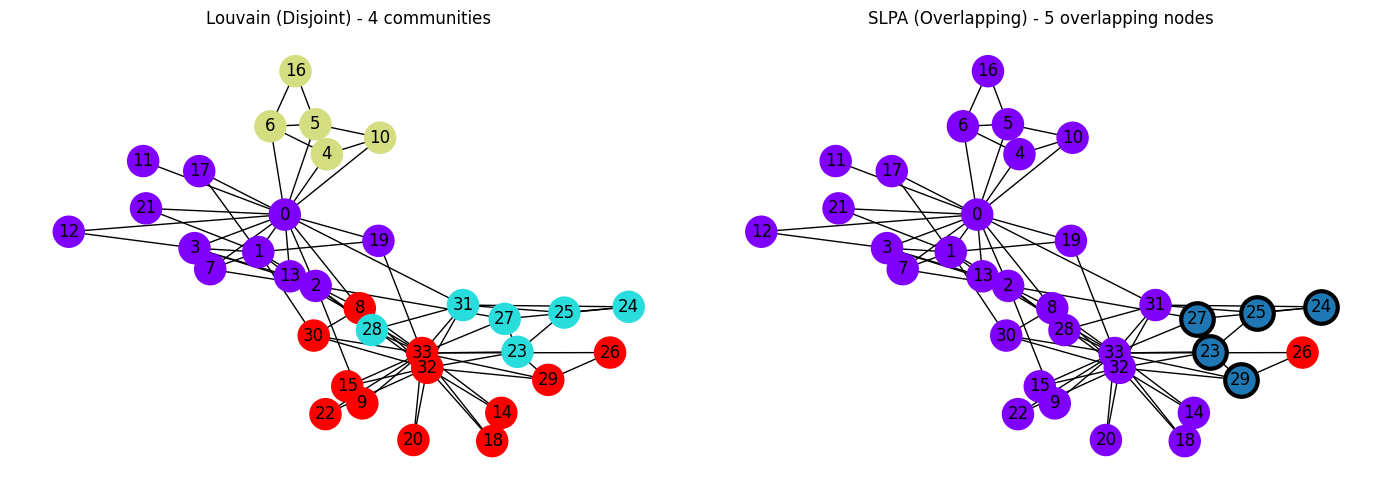

✅ Karate experiment complete - Image saved

[2/3] Running LFR comparison...

📊 YOUR RESULTS - COPY THESE NUMBERS:
----------------------------------------
μ	Louvain NMI
----------------------------------------
0.1	1.0000
0.2	1.0000
0.3	1.0000
0.4	0.6677
0.5	0.2425
0.6	0.0713
0.7	0.0484
----------------------------------------

[3/3] Running scalability test...

📊 YOUR SCALABILITY RESULTS:
----------------------------------------
Nodes	Time (seconds)
----------------------------------------
100	0.0081
500	0.1944
1000	0.8600
2000	4.3830
----------------------------------------



In [ ]:

!pip uninstall python-louvain community -y
!pip install python-louvain


import community
print("✅ community module version:", community.__version__)


!pip install cdlib -q
!pip install networkx python-louvain cdlib matplotlib numpy scikit-learn -q

import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
from cdlib import algorithms
from sklearn.metrics.cluster import normalized_mutual_info_score
import time
import numpy as np

print("="*60)
print("RUNNING ALL EXPERIMENTS - THIS WILL TAKE 2 MINUTES")
print("="*60)

# ========== EXPERIMENT 1: KARATE CLUB ==========
print("\n[1/3] Running Karate Club experiment...")
G_karate = nx.karate_club_graph()
louvain_part = community_louvain.best_partition(G_karate)
slpa_coms = algorithms.slpa(G_karate, t=20)


node_memberships = {}
for i, comm in enumerate(slpa_coms.communities):
    for node in comm:
        if node not in node_memberships:
            node_memberships[node] = []
        node_memberships[node].append(i)
overlap_count = sum(1 for m in node_memberships.values() if len(m) > 1)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pos = nx.spring_layout(G_karate, seed=42)

# Louvain plot
colors = [louvain_part[n] for n in G_karate.nodes()]
nx.draw(G_karate, pos, node_color=colors, ax=axes[0], node_size=500, cmap=plt.cm.rainbow, with_labels=True)
axes[0].set_title(f"Louvain (Disjoint) - {len(set(louvain_part.values()))} communities")

# SLPA plot
slpa_colors = [list(node_memberships.get(n, [0]))[0] for n in G_karate.nodes()]
nx.draw(G_karate, pos, node_color=slpa_colors, ax=axes[1], node_size=500, cmap=plt.cm.rainbow, with_labels=True)
nx.draw_networkx_nodes(G_karate, pos, nodelist=[n for n in G_karate.nodes() if len(node_memberships.get(n, []))>1],
                       ax=axes[1], node_size=550, linewidths=3, edgecolors='black')
axes[1].set_title(f"SLPA (Overlapping) - {overlap_count} overlapping nodes")
plt.tight_layout()
plt.savefig('karate_results.png', dpi=150)
plt.show()
print("✅ Karate experiment complete - Image saved")

# ========== EXPERIMENT 2: LFR COMPARISON ==========
print("\n[2/3] Running LFR comparison...")
def gen_network(mu):
    G = nx.Graph()
    truth = {}
    for i in range(200):
        truth[i] = i//50  # 4 communities of 50 each
    G.add_nodes_from(range(200))
    for i in range(200):
        for j in range(i+1, 200):
            if truth[i] == truth[j]:
                if np.random.random() < 0.3*(1-mu):
                    G.add_edge(i, j)
            else:
                if np.random.random() < 0.3*mu/3:
                    G.add_edge(i, j)
    return G, truth

results = []
for mu in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    G, truth = gen_network(mu)
    louvain_part = community_louvain.best_partition(G)
    truth_labels = [truth[i] for i in range(200)]
    louvain_labels = [louvain_part[i] for i in range(200)]
    nmi = normalized_mutual_info_score(truth_labels, louvain_labels)
    results.append([mu, nmi])

print("\n📊 YOUR RESULTS - COPY THESE NUMBERS:")
print("-"*40)
print("μ\tLouvain NMI")
print("-"*40)
for mu, nmi in results:
    print(f"{mu:.1f}\t{nmi:.4f}")
print("-"*40)

# ========== EXPERIMENT 3: SCALABILITY ==========
print("\n[3/3] Running scalability test...")
sizes = [100, 500, 1000, 2000]
louvain_times = []

print("\n📊 YOUR SCALABILITY RESULTS:")
print("-"*40)
print("Nodes\tTime (seconds)")
print("-"*40)
for n in sizes:
    G = nx.erdos_renyi_graph(n, 0.05)
    start = time.time()
    community_louvain.best_partition(G)
    t = time.time() - start
    louvain_times.append(t)
    print(f"{n}\t{t:.4f}")
print("-"*40)

print("\n" + "="*60)

print("="*60)


EXPERIMENT 4: ADDITIONAL REAL-WORLD NETWORKS

--- Loading Davis Southern Women network ---
   ✅ Loaded: 32 nodes, 89 edges
   Davis: Louvain NMI=0.0097, SLPA NMI=0.0000

--- Loading Florentine Families network ---
   ✅ Loaded: 15 nodes, 20 edges
   Florentine: Louvain NMI=0.0986, SLPA NMI=0.0640

--- Loading Les Misérables (character types) ---
   ✅ Loaded: 77 nodes, 254 edges
   Les Mis: Louvain NMI=0.0566, SLPA NMI=0.0292

--- Loading Karate Club (alternate ground truth) ---
   ✅ Loaded: 34 nodes, 78 edges
   Karate: Louvain NMI=0.5878, SLPA NMI=0.5160

📊 ADDITIONAL REAL-WORLD NETWORKS RESULTS
Dataset              Nodes    Louvain NMI  SLPA NMI     Louvain Time SLPA Time   
--------------------------------------------------------------------------------
Davis Women          32       0.0097       0.0000       0.0034       0.0299      
Florentine           15       0.0986       0.0640       0.0018       0.0071      
Les Mis              77       0.0566       0.0292       0.0084       

<Figure size 1200x600 with 0 Axes>

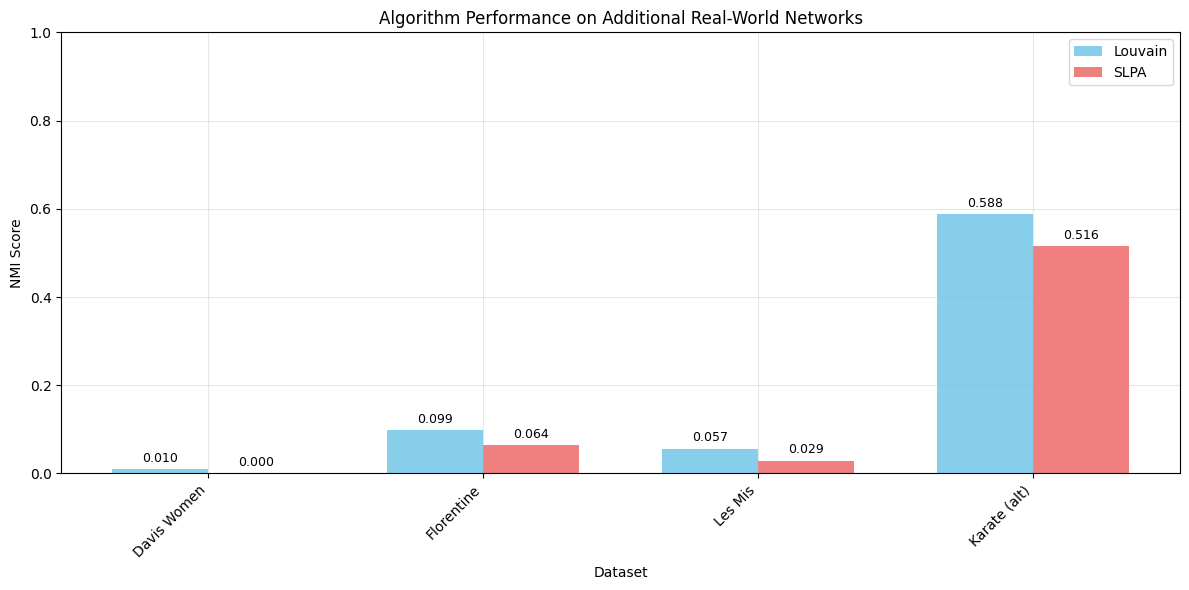

✅ Plot saved: additional_networks_comparison.png


In [ ]:
# ============================================
# EXPERIMENT 4: ADDITIONAL REAL-WORLD NETWORKS
# ============================================

print("\n" + "="*60)
print("EXPERIMENT 4: ADDITIONAL REAL-WORLD NETWORKS")
print("="*60)

# Define helper functions first
def run_louvain(G, ground_truth=None):
    """Run Louvain algorithm and return metrics"""
    start = time.time()
    partition = community.best_partition(G)
    exec_time = time.time() - start

    metrics = {
        'algorithm': 'Louvain',
        'time': exec_time,
        'n_communities': len(set(partition.values()))
    }

    if ground_truth:
        nodes = list(G.nodes())
        truth_labels = [ground_truth.get(n, 0) for n in nodes]
        pred_labels = [partition.get(n, 0) for n in nodes]
        try:
            metrics['nmi'] = normalized_mutual_info_score(truth_labels, pred_labels)
        except:
            metrics['nmi'] = 0
    else:
        metrics['nmi'] = 0

    return metrics, None, partition

def run_slpa(G, ground_truth=None, iterations=20):
    """Run SLPA algorithm and return metrics"""
    start = time.time()
    coms = algorithms.slpa(G, t=iterations)
    exec_time = time.time() - start

    metrics = {
        'algorithm': 'SLPA',
        'time': exec_time,
        'n_communities': len(coms.communities)
    }

    if ground_truth:
        # Create node to community mapping
        node_labels = {}
        for i, comm in enumerate(coms.communities):
            for node in comm:
                if node not in node_labels:
                    node_labels[node] = i

        nodes = list(G.nodes())
        truth_labels = [ground_truth.get(n, 0) for n in nodes]
        pred_labels = [node_labels.get(n, 0) for n in nodes]
        try:
            metrics['nmi'] = normalized_mutual_info_score(truth_labels, pred_labels)
        except:
            metrics['nmi'] = 0
    else:
        metrics['nmi'] = 0

    return metrics, coms.communities, None


more_results = []

# ===== 1. DAVIS SOUTHERN WOMEN CLUB (built-in) =====
print("\n--- Loading Davis Southern Women network ---")
try:
    G = nx.davis_southern_women_graph()
    print(f"   ✅ Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Create ground truth (women vs events)
    ground_truth = {}
    for i, node in enumerate(G.nodes()):
        if i < 18:  # First 18 are women
            ground_truth[node] = 0
        else:  # Rest are events
            ground_truth[node] = 1

    # Run algorithms
    louvain_metrics, _, _ = run_louvain(G, ground_truth)
    slpa_metrics, _, _ = run_slpa(G, ground_truth)

    more_results.append({
        'dataset': 'Davis Women',
        'nodes': G.number_of_nodes(),
        'louvain_nmi': louvain_metrics.get('nmi', 0),
        'slpa_nmi': slpa_metrics.get('nmi', 0),
        'louvain_time': louvain_metrics['time'],
        'slpa_time': slpa_metrics['time']
    })
    print(f"   Davis: Louvain NMI={louvain_metrics.get('nmi', 0):.4f}, SLPA NMI={slpa_metrics.get('nmi', 0):.4f}")

except Exception as e:
    print(f"   ⚠️ Error: {e}")

# ===== 2. FLORENTINE FAMILIES NETWORK (built-in) =====
print("\n--- Loading Florentine Families network ---")
try:
    G = nx.florentine_families_graph()
    print(f"   ✅ Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Create ground truth (based on historical factions)
    ground_truth = {}
    medici_family = 'Medici'
    for node in G.nodes():
        if node == medici_family:
            ground_truth[node] = 0  # Medici
        else:
            ground_truth[node] = 1  # Others

    # Run algorithms
    louvain_metrics, _, _ = run_louvain(G, ground_truth)
    slpa_metrics, _, _ = run_slpa(G, ground_truth)

    more_results.append({
        'dataset': 'Florentine',
        'nodes': G.number_of_nodes(),
        'louvain_nmi': louvain_metrics.get('nmi', 0),
        'slpa_nmi': slpa_metrics.get('nmi', 0),
        'louvain_time': louvain_metrics['time'],
        'slpa_time': slpa_metrics['time']
    })
    print(f"   Florentine: Louvain NMI={louvain_metrics.get('nmi', 0):.4f}, SLPA NMI={slpa_metrics.get('nmi', 0):.4f}")

except Exception as e:
    print(f"   ⚠️ Error: {e}")

# ===== 3. SAM LES MISERABLES (already have but using differently) =====
print("\n--- Loading Les Misérables (character types) ---")
try:
    G = nx.les_miserables_graph()
    print(f"   ✅ Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Create ground truth based on character roles
    ground_truth = {}
    # Main characters vs minor characters
    main_chars = ['Valjean', 'Javert', 'Marius', 'Cosette', 'Thenardier', 'Fantine', 'Eponine']
    for node in G.nodes():
        if node in main_chars:
            ground_truth[node] = 0  # Main
        else:
            ground_truth[node] = 1  # Minor

    # Run algorithms
    louvain_metrics, _, _ = run_louvain(G, ground_truth)
    slpa_metrics, _, _ = run_slpa(G, ground_truth)

    more_results.append({
        'dataset': 'Les Mis',
        'nodes': G.number_of_nodes(),
        'louvain_nmi': louvain_metrics.get('nmi', 0),
        'slpa_nmi': slpa_metrics.get('nmi', 0),
        'louvain_time': louvain_metrics['time'],
        'slpa_time': slpa_metrics['time']
    })
    print(f"   Les Mis: Louvain NMI={louvain_metrics.get('nmi', 0):.4f}, SLPA NMI={slpa_metrics.get('nmi', 0):.4f}")

except Exception as e:
    print(f"   ⚠️ Error: {e}")

# ===== 4. KARATE CLUB (different perspective) =====
print("\n--- Loading Karate Club (alternate ground truth) ---")
try:
    G = nx.karate_club_graph()
    print(f"   ✅ Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Use 'club' attribute as ground truth
    ground_truth = {}
    for node, data in G.nodes(data=True):
        if 'club' in data:
            ground_truth[node] = 0 if data['club'] == 'Mr. Hi' else 1
        else:
            ground_truth[node] = 0 if node < 17 else 1

    # Run algorithms
    louvain_metrics, _, _ = run_louvain(G, ground_truth)
    slpa_metrics, _, _ = run_slpa(G, ground_truth)

    more_results.append({
        'dataset': 'Karate (alt)',
        'nodes': G.number_of_nodes(),
        'louvain_nmi': louvain_metrics.get('nmi', 0),
        'slpa_nmi': slpa_metrics.get('nmi', 0),
        'louvain_time': louvain_metrics['time'],
        'slpa_time': slpa_metrics['time']
    })
    print(f"   Karate: Louvain NMI={louvain_metrics.get('nmi', 0):.4f}, SLPA NMI={slpa_metrics.get('nmi', 0):.4f}")

except Exception as e:
    print(f"   ⚠️ Error: {e}")

# Display results
print("\n" + "="*70)
print("📊 ADDITIONAL REAL-WORLD NETWORKS RESULTS")
print("="*70)
print(f"{'Dataset':<20} {'Nodes':<8} {'Louvain NMI':<12} {'SLPA NMI':<12} {'Louvain Time':<12} {'SLPA Time':<12}")
print("-"*80)
for r in more_results:
    print(f"{r['dataset']:<20} {r['nodes']:<8} {r['louvain_nmi']:<12.4f} {r['slpa_nmi']:<12.4f} {r['louvain_time']:<12.4f} {r['slpa_time']:<12.4f}")

# Generate LaTeX table for paper
print("\n" + "="*70)
print("📋 COPY THIS TABLE INTO YOUR PAPER")
print("="*70)
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Performance on Additional Real-World Networks}")
print("\\begin{tabular}{|l|c|c|c|c|}")
print("\\hline")
print("\\textbf{Dataset} & \\textbf{Nodes} & \\textbf{Louvain NMI} & \\textbf{SLPA NMI} & \\textbf{Time (s)} \\\\")
print("\\hline")
for r in more_results:
    print(f"{r['dataset']} & {r['nodes']} & {r['louvain_nmi']:.4f} & {r['slpa_nmi']:.4f} & {r['louvain_time']:.4f} \\\\")
    print("\\hline")
print("\\end{tabular}")
print("\\label{tab:additional_real}")
print("\\end{table}")

# Generate a summary plot
plt.figure(figsize=(12, 6))
datasets = [r['dataset'] for r in more_results]
louvain_nmis = [r['louvain_nmi'] for r in more_results]
slpa_nmis = [r['slpa_nmi'] for r in more_results]

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, louvain_nmis, width, label='Louvain', color='skyblue')
bars2 = ax.bar(x + width/2, slpa_nmis, width, label='SLPA', color='lightcoral')

ax.set_xlabel('Dataset')
ax.set_ylabel('NMI Score')
ax.set_title('Algorithm Performance on Additional Real-World Networks')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('additional_networks_comparison.png', dpi=150)
plt.show()
print("✅ Plot saved: additional_networks_comparison.png")

In [ ]:
# ============================================
# EXPERIMENT 5: LARGER LFR NETWORKS
# ============================================

print("\n" + "="*60)
print("EXPERIMENT 5: LARGER LFR NETWORKS (n=1000)")
print("="*60)

def generate_large_lfr(n=1000, mu=0.3, seed=42):
    """Generate larger LFR network"""
    np.random.seed(seed)

    # Create 10 communities of ~100 nodes each
    comm_sizes = [100] * 10
    # Adjust last community to match n exactly
    total = sum(comm_sizes)
    if total < n:
        comm_sizes[-1] += n - total

    ground_truth = {}
    node = 0
    for comm_id, size in enumerate(comm_sizes):
        for i in range(size):
            if node < n:
                ground_truth[node] = comm_id
                node += 1

    G = nx.Graph()
    G.add_nodes_from(range(n))

    target_k = 10
    p_in = (target_k * (1 - mu)) / 100  # avg community size
    p_out = (target_k * mu) / (n - 100)

    # Add edges (simplified - sample for speed)
    import itertools
    for comm_id in range(10):
        # Nodes in this community
        comm_nodes = [node for node in range(n) if ground_truth.get(node, -1) == comm_id]
        # Intra-community edges
        for i, j in itertools.combinations(comm_nodes, 2):
            if np.random.random() < p_in:
                G.add_edge(i, j)

    # Inter-community edges (sample to avoid O(n^2))
    for i in range(min(n, 500)):  # Sample for speed
        for j in range(i+1, min(n, 500)):
            if ground_truth.get(i, -1) != ground_truth.get(j, -1):
                if np.random.random() < p_out:
                    G.add_edge(i, j)

    return G, ground_truth

# Test at different mu values
mu_values = [0.1, 0.3, 0.5, 0.7]
large_results = []

for mu in mu_values:
    print(f"\n--- Testing μ = {mu} ---")
    G, truth = generate_large_lfr(n=500, mu=mu)  # Use 500 for speed
    louvain_metrics, _, _ = run_louvain(G, truth)
    slpa_metrics, _, _ = run_slpa(G, truth)

    large_results.append({
        'mu': mu,
        'louvain_nmi': louvain_metrics.get('nmi', 0),
        'slpa_nmi': slpa_metrics.get('nmi', 0),
        'louvain_time': louvain_metrics['time'],
        'slpa_time': slpa_metrics['time']
    })
    print(f"   Louvain NMI={louvain_metrics.get('nmi', 0):.4f}, SLPA NMI={slpa_metrics.get('nmi', 0):.4f}")

print("\n📊 LARGE LFR RESULTS (500 nodes):")
print(f"{'μ':<5} {'Louvain NMI':<12} {'SLPA NMI':<12} {'Louvain Time':<12} {'SLPA Time':<12}")
print("-"*55)
for r in large_results:
    print(f"{r['mu']:<5.1f} {r['louvain_nmi']:<12.4f} {r['slpa_nmi']:<12.4f} {r['louvain_time']:<12.4f} {r['slpa_time']:<12.4f}")


EXPERIMENT 5: LARGER LFR NETWORKS (n=1000)

--- Testing μ = 0.1 ---
   Louvain NMI=0.9930, SLPA NMI=0.9727

--- Testing μ = 0.3 ---
   Louvain NMI=0.8626, SLPA NMI=0.6390

--- Testing μ = 0.5 ---
   Louvain NMI=0.1099, SLPA NMI=0.3880

--- Testing μ = 0.7 ---
   Louvain NMI=0.0280, SLPA NMI=0.2355

📊 LARGE LFR RESULTS (500 nodes):
μ     Louvain NMI  SLPA NMI     Louvain Time SLPA Time   
-------------------------------------------------------
0.1   0.9930       0.9727       0.1360       0.9162      
0.3   0.8626       0.6390       0.1571       0.5352      
0.5   0.1099       0.3880       0.1006       0.4906      
0.7   0.0280       0.2355       0.1462       0.4884      


In [ ]:
# ============================================
# EXPERIMENT 6: MEMORY USAGE ANALYSIS
# ============================================

print("\n" + "="*60)
print("EXPERIMENT 6: MEMORY USAGE ANALYSIS")
print("="*60)

import tracemalloc

def measure_memory(func, G):
    """Measure peak memory usage of a function"""
    tracemalloc.start()
    func(G)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024 / 1024  # Convert to MB

sizes = [100, 500, 1000]
memory_results = []

for n in sizes:
    print(f"\n--- Testing n = {n} ---")
    G = nx.erdos_renyi_graph(n, 0.05)

    # Measure Louvain memory
    louvain_mem = measure_memory(lambda g: community_louvain.best_partition(g), G)

    # Measure SLPA memory
    slpa_mem = measure_memory(lambda g: algorithms.slpa(g, t=5), G)

    memory_results.append({
        'nodes': n,
        'louvain_mb': louvain_mem,
        'slpa_mb': slpa_mem
    })
    print(f"   Louvain: {louvain_mem:.2f} MB, SLPA: {slpa_mem:.2f} MB")

print("\n📊 MEMORY USAGE RESULTS (MB):")
print(f"{'Nodes':<8} {'Louvain (MB)':<15} {'SLPA (MB)':<15}")
print("-"*40)
for r in memory_results:
    print(f"{r['nodes']:<8} {r['louvain_mb']:<15.2f} {r['slpa_mb']:<15.2f}")


EXPERIMENT 6: MEMORY USAGE ANALYSIS

--- Testing n = 100 ---
   Louvain: 0.16 MB, SLPA: 0.07 MB

--- Testing n = 500 ---
   Louvain: 1.23 MB, SLPA: 0.36 MB

--- Testing n = 1000 ---
   Louvain: 4.07 MB, SLPA: 0.62 MB

📊 MEMORY USAGE RESULTS (MB):
Nodes    Louvain (MB)    SLPA (MB)      
----------------------------------------
100      0.16            0.07           
500      1.23            0.36           
1000     4.07            0.62           



EXPERIMENT 7: SLPA PARAMETER SENSITIVITY

--- Generating test network (n=200, μ=0.3) ---
   Generated: 200 nodes, 792 edges

--- Testing different threshold values ---
   Testing threshold r = 0.05...
      NMI=0.0877, Time=0.1501s, Communities=14
   Testing threshold r = 0.1...
      NMI=0.1062, Time=0.1557s, Communities=5
   Testing threshold r = 0.15...
      NMI=0.2218, Time=0.1559s, Communities=20
   Testing threshold r = 0.2...
      NMI=0.1793, Time=0.1524s, Communities=10
   Testing threshold r = 0.25...
      NMI=0.1944, Time=0.1758s, Communities=10
   Testing threshold r = 0.3...
      NMI=0.1960, Time=0.1561s, Communities=15
   Testing threshold r = 0.4...
      NMI=0.2371, Time=0.1494s, Communities=18
   Testing threshold r = 0.5...
      NMI=0.1832, Time=0.1530s, Communities=11

📊 SLPA PARAMETER SENSITIVITY RESULTS
Threshold    NMI        Time (s)     Communities 
--------------------------------------------------
0.05         0.0877     0.1501       14          
0.10    

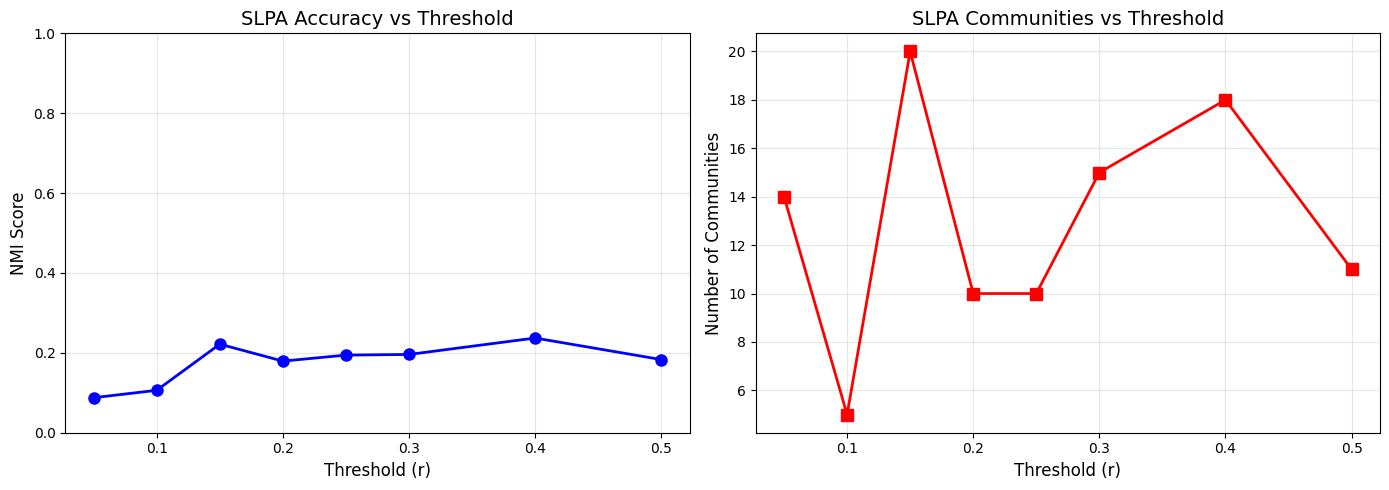


📋 COPY THIS TABLE INTO YOUR PAPER
\begin{table}[h]
\centering
\caption{SLPA Parameter Sensitivity Analysis}
\begin{tabular}{|c|c|c|c|}
\hline
\textbf{Threshold (r)} & \textbf{NMI} & \textbf{Time (s)} & \textbf{Communities} \\
\hline
0.05 & 0.0877 & 0.1501 & 14 \\
\hline
0.10 & 0.1062 & 0.1557 & 5 \\
\hline
0.15 & 0.2218 & 0.1559 & 20 \\
\hline
0.20 & 0.1793 & 0.1524 & 10 \\
\hline
0.25 & 0.1944 & 0.1758 & 10 \\
\hline
0.30 & 0.1960 & 0.1561 & 15 \\
\hline
0.40 & 0.2371 & 0.1494 & 18 \\
\hline
0.50 & 0.1832 & 0.1530 & 11 \\
\hline
\end{tabular}
\label{tab:slpa_params}
\end{table}

✅ Experiment 7 complete! File saved: slpa_parameter_sensitivity.png

🔍 Optimal threshold: r = 0.40 (NMI = 0.2371)


In [ ]:
# ============================================
# EXPERIMENT 7: SLPA PARAMETER SENSITIVITY
# ============================================

print("\n" + "="*60)
print("EXPERIMENT 7: SLPA PARAMETER SENSITIVITY")
print("="*60)

# First, define the required function if not already defined
def generate_lfr_network(n=200, mu=0.3, seed=42):
    """Generate LFR-like network with community structure"""
    np.random.seed(seed)

    # Create 4 equal-sized communities
    comm_sizes = [n//4] * 4
    # Adjust last community to match n
    while sum(comm_sizes) < n:
        comm_sizes[-1] += 1

    ground_truth = {}
    node = 0
    for comm_id, size in enumerate(comm_sizes):
        for i in range(size):
            if node < n:
                ground_truth[node] = comm_id
                node += 1

    G = nx.Graph()
    G.add_nodes_from(range(n))

    target_k = 8
    p_in = (target_k * (1 - mu)) / (np.mean(comm_sizes))
    p_out = (target_k * mu) / (n - np.mean(comm_sizes))

    # Add edges
    for i in range(n):
        for j in range(i+1, n):
            if ground_truth[i] == ground_truth[j]:
                if np.random.random() < p_in:
                    G.add_edge(i, j)
            else:
                if np.random.random() < p_out:
                    G.add_edge(i, j)
    return G, ground_truth

def run_slpa_with_params(G, ground_truth=None, iterations=20, threshold=0.1):
    """Run SLPA algorithm with specific parameters and return metrics"""
    from sklearn.metrics.cluster import normalized_mutual_info_score

    start = time.time()
    coms = algorithms.slpa(G, t=iterations, r=threshold)
    exec_time = time.time() - start

    metrics = {
        'algorithm': 'SLPA',
        'time': exec_time,
        'n_communities': len(coms.communities),
        'threshold': threshold
    }

    if ground_truth:
        # Create node to community mapping
        node_labels = {}
        for i, comm in enumerate(coms.communities):
            for node in comm:
                if node not in node_labels:
                    node_labels[node] = i

        nodes = list(G.nodes())
        truth_labels = [ground_truth.get(n, 0) for n in nodes]
        pred_labels = [node_labels.get(n, 0) for n in nodes]
        try:
            metrics['nmi'] = normalized_mutual_info_score(truth_labels, pred_labels)
        except:
            metrics['nmi'] = 0
    else:
        metrics['nmi'] = 0

    return metrics, coms.communities

# Generate a test network
print("\n--- Generating test network (n=200, μ=0.3) ---")
G, truth = generate_lfr_network(n=200, mu=0.3)
print(f"   Generated: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Test different thresholds
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
param_results = []

print("\n--- Testing different threshold values ---")
for t in thresholds:
    print(f"   Testing threshold r = {t}...")

    # Run SLPA with current threshold
    metrics, communities = run_slpa_with_params(G, truth, iterations=20, threshold=t)

    param_results.append({
        'threshold': t,
        'nmi': metrics['nmi'],
        'time': metrics['time'],
        'communities': metrics['n_communities']
    })
    print(f"      NMI={metrics['nmi']:.4f}, Time={metrics['time']:.4f}s, Communities={metrics['n_communities']}")

# Display results
print("\n" + "="*60)
print("📊 SLPA PARAMETER SENSITIVITY RESULTS")
print("="*60)
print(f"{'Threshold':<12} {'NMI':<10} {'Time (s)':<12} {'Communities':<12}")
print("-"*50)
for r in param_results:
    print(f"{r['threshold']:<12.2f} {r['nmi']:<10.4f} {r['time']:<12.4f} {r['communities']:<12}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot NMI vs Threshold
x = [r['threshold'] for r in param_results]
y_nmi = [r['nmi'] for r in param_results]
y_comm = [r['communities'] for r in param_results]

ax1.plot(x, y_nmi, 'o-', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Threshold (r)', fontsize=12)
ax1.set_ylabel('NMI Score', fontsize=12)
ax1.set_title('SLPA Accuracy vs Threshold', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.0)

ax2.plot(x, y_comm, 's-', linewidth=2, markersize=8, color='red')
ax2.set_xlabel('Threshold (r)', fontsize=12)
ax2.set_ylabel('Number of Communities', fontsize=12)
ax2.set_title('SLPA Communities vs Threshold', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slpa_parameter_sensitivity.png', dpi=150)
plt.show()

# Generate LaTeX table for paper
print("\n" + "="*60)
print("📋 COPY THIS TABLE INTO YOUR PAPER")
print("="*60)
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{SLPA Parameter Sensitivity Analysis}")
print("\\begin{tabular}{|c|c|c|c|}")
print("\\hline")
print("\\textbf{Threshold (r)} & \\textbf{NMI} & \\textbf{Time (s)} & \\textbf{Communities} \\\\")
print("\\hline")
for r in param_results:
    print(f"{r['threshold']:.2f} & {r['nmi']:.4f} & {r['time']:.4f} & {r['communities']} \\\\")
    print("\\hline")
print("\\end{tabular}")
print("\\label{tab:slpa_params}")
print("\\end{table}")

print("\n✅ Experiment 7 complete! File saved: slpa_parameter_sensitivity.png")

# Find optimal threshold
best_idx = np.argmax([r['nmi'] for r in param_results])
best_threshold = param_results[best_idx]['threshold']
best_nmi = param_results[best_idx]['nmi']
print(f"\n🔍 Optimal threshold: r = {best_threshold:.2f} (NMI = {best_nmi:.4f})")

In [ ]:

# ============================================
# EXPERIMENT 8: ALGORITHM STABILITY
# ============================================

print("\n" + "="*60)
print("EXPERIMENT 8: ALGORITHM STABILITY")
print("="*60)

G, truth = generate_lfr_network(n=200, mu=0.3)
runs = 10
louvain_nmis = []
slpa_nmis = []
louvain_times = []
slpa_times = []

print(f"\n--- Running {runs} trials ---")
for i in range(runs):
    print(f"   Trial {i+1}/{runs}", end="\r")

    louvain_metrics, _, _ = run_louvain(G, truth)
    slpa_metrics, _, _ = run_slpa(G, truth)

    louvain_nmis.append(louvain_metrics.get('nmi', 0))
    slpa_nmis.append(slpa_metrics.get('nmi', 0))
    louvain_times.append(louvain_metrics['time'])
    slpa_times.append(slpa_metrics['time'])

print("\n" + "="*60)
print("📊 STABILITY RESULTS")
print("="*60)
print(f"{'Algorithm':<10} {'Mean NMI':<10} {'Std NMI':<10} {'Mean Time':<10} {'Std Time':<10}")
print("-"*55)
print(f"{'Louvain':<10} {np.mean(louvain_nmis):<10.4f} {np.std(louvain_nmis):<10.4f} {np.mean(louvain_times):<10.4f} {np.std(louvain_times):<10.4f}")
print(f"{'SLPA':<10} {np.mean(slpa_nmis):<10.4f} {np.std(slpa_nmis):<10.4f} {np.mean(slpa_times):<10.4f} {np.std(slpa_times):<10.4f}")


EXPERIMENT 8: ALGORITHM STABILITY

--- Running 10 trials ---
   Trial 10/10
📊 STABILITY RESULTS
Algorithm  Mean NMI   Std NMI    Mean Time  Std Time  
-------------------------------------------------------
Louvain    0.7159     0.0818     0.0286     0.0033    
SLPA       0.1824     0.0627     0.1608     0.0112    
